In [1]:
import numpy as np
import cv2
import os
from matplotlib import pyplot as plt
from sklearn.metrics import r2_score
import math
import sys
from numpy.polynomial import Chebyshev, Polynomial
from scipy.ndimage import label
import numpy.polynomial.polynomial as poly
from PIL import Image
import warnings
np.set_printoptions(threshold=sys.maxsize)

In [2]:
def load_images_from_folder(folder):
    images = []
    for filename in os.listdir(folder):
        img = cv2.imread(os.path.join(folder,filename))
        if img is not None:
            images.append(img)
    return images

In [3]:
pics = np.zeros(shape=(7, 256, 256, 3))
pics = load_images_from_folder('C:\\Users\\2020\\Documents\\3 Academics\\Cambridge\\Publications\\Computer Vision\\Figures and Original Soln\\pics')

In [4]:
img1 = pics[-2].astype('uint8')
img1[2][2] = 50; img1[2][6] = 0; img1[3][2] = 50; img1[3][3] = 50; img1[3][4] = 50; img1[3][5] = 50; img1[4][2] = 50; img1[4][4] = 0
img1[4][5] = 50; img1[4][6] = 50; img1[5][2] = 50; img1[5][3] = 50; img1[5][4] = 50; img1[5][5] = 50; img1[5][6] = 50

img2 = pics[-2].astype('uint8')
img2[2][2] = 50; img2[2][6] = 0; img2[3][2] = 50; img2[3][3] = 50; img2[3][4] = 50; img2[3][5] = 50; img2[4][2] = 50; img2[4][4] = 0
img2[4][5] = 50; img2[4][6] = 50; img2[5][2] = 50; img2[5][3] = 50; img2[5][4] = 50; img2[5][5] = 50; img2[5][6] = 50
img2[0][0] = [255,255,60]; img2[0][1] = [255,255,60]; img2[0][2] = [255,255,60];   img2[0][3] = [255,255,60]; img2[0][4] = [255,255,60]
img2[0][5] = [255,255,60]; img2[0][6] = [255,255,60]; img2[0][7] = [255,255,60]; img2[7][0] = [255,255,60]; img2[7][1] = [255,255,60]
img2[7][2] = [255,255,60]; img2[7][3] = [255,255,60]; img2[7][4] = [255,255,60]; img2[7][5] = [255,255,60]; img2[7][6] = [255,255,60]
img2[7][7] = [255,255,60]; img2[1][0] = [255,255,60]; img2[2][0] = [255,255,60]; img2[3][0] = [255,255,60]; img2[4][0] = [255,255,60]
img2[5][0] = [255,255,60]; img2[6][0] = [255,255,60]; img2[1][7] = [255,255,60]; img2[2][7] = [255,255,60]; img2[3][7] = [255,255,60]
img2[4][7] = [255,255,60]; img2[5][7] = [255,255,60]; img2[6][7] = [255,255,60]; img2[1][1] = [255,255,60]; img2[2][1] = [255,255,60]
img2[3][1] = [255,255,60]; img2[4][1] = [255,255,60]; img2[5][1] = [255,255,60]; img2[6][1] = [255,255,60]; img2[6][2] = [255,255,60]
img2[6][3] = [255,255,60]; img2[6][4] = [255,255,60]; img2[6][5] = [255,255,60]; img2[6][6] = [255,255,60]; img2[6][7] = [255,255,60]
img2[3][6] = [60,255,255]
#f, axarr = plt.subplots(1,2)
#axarr[0].imshow(img1[...,::-1])
#axarr[1].imshow(img2[...,::-1])

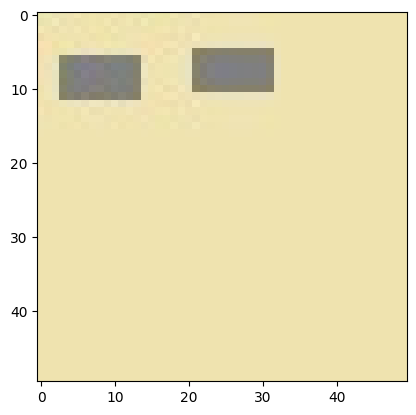

In [ ]:
chosenImage = pics[3]

#HYPERPARAMETERS
thresh = 0.01               # color similarity threshold
percentMerge = 0.05         # percentage of clusters to merge

# Convert BGR to RGB for PIL (PIL expects RGB format)
chosenImageRGB = cv2.cvtColor(chosenImage, cv2.COLOR_BGR2RGB)
im = Image.fromarray(chosenImageRGB)
im.save('test.png')
im.save('test.jpg')
im.save('test.tiff')
plt.imshow(cv2.cvtColor(chosenImage, cv2.COLOR_RGB2BGR))
plt.show()



In [6]:
def checkFit(cMean, pixel):
    # Compute current cluster mean
    h_mean = np.mean(cMean[0])
    s_mean = np.mean(cMean[1])
    v_mean = np.mean(cMean[2])
    
    # Circular hue difference (normalized to [0,1])
    dh = min(abs(pixel[0] - h_mean), 180 - abs(pixel[0] - h_mean)) / 180.0
    
    # Saturation and value differences (normalized)
    ds = abs(pixel[1] - s_mean) / 255.0
    dv = abs(pixel[2] - v_mean) / 255.0
    
    # Weighted distance: emphasize hue, de-emphasize value
    return np.sqrt((2 * dh)**2 + ds**2 + (0.5 * dv)**2)

In [ ]:
# Convert input image to HSV
img = cv2.cvtColor(chosenImage, cv2.COLOR_BGR2HSV)

# Remove old compressed file if it exists 
if os.path.exists("imComp.txt"):
    os.remove("imComp.txt")

# imgClusters[i,j] = cluster number pixel belongs to
imgClusters = np.ones((img.shape[0], img.shape[1]), dtype=int)

# List of perimeter pixels for each cluster
clusterEdges = []

# visited[i,j] = 1 - pixel not yet assigned to any cluster
# visited[i,j] = 0 - pixel already assigned
visited = np.ones((img.shape[0], img.shape[1]), dtype=int)

clusterNum = 1              # current cluster ID
clustMeans = []             # mean HSV per cluster

# 4-connected neighborhood definition
structure = np.array([[0,1,0],
                      [1,1,1],
                      [0,1,0]])

# Continue until all pixels have been assigned
while np.count_nonzero(visited) > 0:

    firstFind = 0            # flag to find seed pixel
    clust = []               # border pixels for this cluster

    # Greedy assumption: all unvisited pixels could be in this cluster
    imgClusters[visited != 0] = clusterNum

    # ---- STEP 1: find the seed pixel and initialize cluster mean ----
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            if visited[i][j] == 1 and firstFind == 0:
                # First unvisited pixel becomes the seed
                startX, startY = i, j

                # Cluster mean stored as lists to allow appending new pixels easily
                cMean = [[], [], []]
                cMean[0].append(img[i][j][0])
                cMean[1].append(img[i][j][1])
                cMean[2].append(img[i][j][2])

                firstFind = 1

    # ---- STEP 2: build the similarity mask, replaces recursion ----
    # fitMask[i,j] = True if pixel is unvisited AND fits cluster mean
    fitMask = np.zeros((img.shape[0], img.shape[1]), dtype=bool)
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            if visited[i][j] == 1:
                if checkFit(cMean, img[i][j]) < thresh:
                    fitMask[i][j] = True

    # ---- STEP 3: connected component labeling (4-connected) ----
    # Each connected region of True pixels gets a unique label
    labels, numLabels = label(fitMask, structure)

    # Label of the connected component containing the seed pixel
    seedLabel = labels[startX, startY]

    # region[i,j] = True ONLY for pixels reachable from the seed
    region = (labels == seedLabel)

    # ---- STEP 4: accept pixels in this connected component ----
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            if region[i][j]:
                visited[i][j] = 0                # mark as assigned
                imgClusters[i][j] = clusterNum   # assign cluster

                # update cluster mean
                cMean[0].append(img[i][j][0])
                cMean[1].append(img[i][j][1])
                cMean[2].append(img[i][j][2])

    # ---- STEP 5: border detection ----
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            if region[i][j]:

                # Check 4 neighbors only (same as recursion logic)
                for di, dj in [(-1,0), (1,0), (0,-1), (0,1)]:
                    ni, nj = i + di, j + dj

                    # Absolute image border - border pixel
                    if ni < 0 or nj < 0 or ni >= img.shape[0] or nj >= img.shape[1]:
                        clust.append((i, j))
                        break

                    # Neighbor not in same component - border pixel
                    if not region[ni][nj]:
                        clust.append((i, j))
                        break

    # ---- STEP 6: finalize this cluster ----
    clusterEdges.append(list(set(clust)))

    clustMeans.append((
        int(np.rint(np.mean(cMean[0]))),
        int(np.rint(np.mean(cMean[1]))),
        int(np.rint(np.mean(cMean[2])))
    ))

    clusterNum += 1


In [ ]:
# Percent merge function
img_area = img.shape[0] * img.shape[1]
rowsToDelete = set()

for i in range(len(clusterEdges)):
    if i in rowsToDelete:
        continue
    if len(clusterEdges[i]) == 0:
        rowsToDelete.add(i)
        continue

    if (len(clusterEdges[i]) / img_area) < percentMerge:
        src_pts = np.array(clusterEdges[i], dtype=float)
        src_center = np.mean(src_pts, axis=0)

        best_j = -1
        best_dist = float('inf')
        for j in range(len(clusterEdges)):
            if j == i or j in rowsToDelete or len(clusterEdges[j]) == 0:
                continue
            dst_pts = np.array(clusterEdges[j], dtype=float)
            dst_center = np.mean(dst_pts, axis=0)
            d = np.linalg.norm(src_center - dst_center)
            if d < best_dist:
                best_dist = d
                best_j = j

        if best_j == -1:
            continue

        for r, c in clusterEdges[i]:
            rr, cc = int(r), int(c)
            if 0 <= rr < img.shape[0] and 0 <= cc < img.shape[1]:
                imgClusters[rr, cc] = best_j + 1

        merged = set(clusterEdges[best_j])
        merged.update(clusterEdges[i])
        clusterEdges[best_j] = list(merged)
        rowsToDelete.add(i)

for row in sorted(rowsToDelete, reverse=True):
    del clusterEdges[row]
    del clustMeans[row]



In [ ]:
# Trace the outer edge of a cluster of pixels.
# Returns ordered X and Y coordinates along the contour.
def traceClusterEdges(cluster):
    if len(cluster) == 0:
        return [], []

    # Convert cluster to set for O(1) membership check
    pixels = set(cluster)

    # clockwise starting from north
    directions = [(-1, 0), (-1, 1), (0, 1), (1, 1),
                  (1, 0), (1, -1), (0, -1), (-1, -1)]

    # Find starting pixel: top-left-most
    start = min(pixels, key=lambda c: (c[1], c[0]))
    x, y = start
    contour = [(x, y)]
    current = start
    prev_dir = 6  # start looking from left neighbor (south-west)

    while True:
        found_next = False
        # Check 8 neighbors clockwise starting from (prev_dir + 1)
        for i in range(8):
            idx = (prev_dir + 1 + i) % 8
            dx, dy = directions[idx]
            neighbor = (current[0] + dx, current[1] + dy)
            if neighbor in pixels:
                contour.append(neighbor)
                current = neighbor
                prev_dir = (idx + 4) % 8  # set new prev_dir opposite direction
                found_next = True
                break
        if not found_next or current == start:
            break

    # Separate X and Y
    X, Y = zip(*contour)
    return list(X), list(Y)

In [10]:
edgesSorted = []
for cluster in clusterEdges:
    xList, yList = traceClusterEdges(cluster)
    edgesSorted.append([xList, yList])

In [ ]:
# Piecewise cubic Bezier helpers
def enforce_closed_contour(x, y):
    pts = [(int(r), int(c)) for r, c in zip(x, y)]
    if not pts:
        return []

    cleaned = [pts[0]]
    for p in pts[1:]:
        if p != cleaned[-1]:
            cleaned.append(p)

    if cleaned[0] != cleaned[-1]:
        cleaned.append(cleaned[0])

    if len(cleaned) < 4:
        return []
    return cleaned


def contour_polygon_area(contour_pts):
    if len(contour_pts) < 4:
        return 0.0
    pts = contour_pts[:-1] if contour_pts[0] == contour_pts[-1] else contour_pts
    if len(pts) < 3:
        return 0.0
    x = np.array([p[1] for p in pts], dtype=float)
    y = np.array([p[0] for p in pts], dtype=float)
    return 0.5 * abs(np.dot(x, np.roll(y, -1)) - np.dot(y, np.roll(x, -1)))


def simplify_contour_dp(contour_pts, eps_ratio=0.02):
    # Simplify contour with Douglas-Peucker in (x,y) = (col,row)
    if len(contour_pts) < 6:
        return contour_pts

    base = contour_pts[:-1] if contour_pts[0] == contour_pts[-1] else contour_pts
    if len(base) < 4:
        return contour_pts

    arr = np.array([[p[1], p[0]] for p in base], dtype=np.float32).reshape((-1, 1, 2))
    peri = cv2.arcLength(arr, True)
    eps = max(0.5, eps_ratio * peri)
    approx = cv2.approxPolyDP(arr, eps, True).reshape((-1, 2))

    simp = [(int(round(y)), int(round(x))) for x, y in approx]
    if len(simp) < 4:
        return contour_pts

    if simp[0] != simp[-1]:
        simp.append(simp[0])
    return simp


def is_valid_contour_for_bezier(contour_pts, min_points=8, min_area=4.0):
    if len(contour_pts) < min_points:
        return False
    if contour_polygon_area(contour_pts) < min_area:
        return False
    return True


def choose_adaptive_stride(contour_pts):
    # Larger stride for longer/smoother contours to reduce micro-segments
    n = len(contour_pts)
    area = contour_polygon_area(contour_pts)
    if n < 20 or area < 20:
        return 2
    if n < 40 or area < 60:
        return 3
    if n < 80 or area < 150:
        return 4
    return 6


def build_piecewise_bezier_segments(contour_pts, stride=4, min_chord=1.0):
    if len(contour_pts) < 5:
        return []

    base = contour_pts[:-1]
    n = len(base)
    if n < 4:
        return []

    stride = max(1, int(stride))
    anchors = [base[i] for i in range(0, n, stride)]
    if len(anchors) < 4:
        anchors = base[:]

    k = len(anchors)
    segments = []

    for i in range(k):
        p0 = np.array(anchors[(i - 1) % k], dtype=float)
        p1 = np.array(anchors[i], dtype=float)
        p2 = np.array(anchors[(i + 1) % k], dtype=float)
        p3 = np.array(anchors[(i + 2) % k], dtype=float)

        b0 = p1
        b1 = p1 + (p2 - p0) / 6.0
        b2 = p2 - (p3 - p1) / 6.0
        b3 = p2

        # Drop tiny degenerate segments
        if np.linalg.norm(b3 - b0) < min_chord:
            continue

        segments.append([tuple(b0), tuple(b1), tuple(b2), tuple(b3)])

    return segments

In [ ]:
# write Bezier when valid, otherwise fallback to loop (L)
with open("imComp.txt", "a") as f:
    for i in range(len(edgesSorted)):
        x = edgesSorted[i][0]
        y = edgesSorted[i][1]

        contour_pts = enforce_closed_contour(x, y)
        contour_pts = simplify_contour_dp(contour_pts, eps_ratio=0.02)

        # Basic validity for any polygonal write
        if len(contour_pts) < 4:
            continue

        stride = choose_adaptive_stride(contour_pts)
        bezier_segments = []

        if is_valid_contour_for_bezier(contour_pts, min_points=8, min_area=4.0):
            bezier_segments = build_piecewise_bezier_segments(contour_pts, stride=stride, min_chord=1.0)

        # Write cluster color only if we can encode some geometry
        if len(bezier_segments) == 0:
            # Fallback loop encoding: L;r,c;r,c;...
            # Downsample loop to keep output bounded.
            base = contour_pts[:-1] if contour_pts[0] == contour_pts[-1] else contour_pts
            if len(base) < 3:
                continue

            loop_step = max(1, len(base) // 40)
            sampled = base[::loop_step]
            if len(sampled) < 3:
                continue
            if sampled[0] != sampled[-1]:
                sampled.append(sampled[0])

            f.write("C;" + str(clustMeans[i][0]) + ',' + str(clustMeans[i][1]) + ',' + str(clustMeans[i][2]) + ';\n')
            payload = ';'.join(f"{pt[0]:.4f},{pt[1]:.4f}" for pt in sampled)
            f.write("L;" + payload + ';\n\n')
            continue

        f.write("C;" + str(clustMeans[i][0]) + ',' + str(clustMeans[i][1]) + ',' + str(clustMeans[i][2]) + ';\n')

        for seg in bezier_segments:
            # Store float control points; round only when rasterizing
            coords = [f"{pt[0]:.4f},{pt[1]:.4f}" for pt in seg]
            f.write("B;" + ';'.join(coords) + ';\n')

        f.write("\n")

In [13]:
#Compare final compression to jpg and png
print("Fish compress:", os.path.getsize('imComp.txt'))
print("JPEG compress:", os.path.getsize('test.jpg'))
print("PNG compress:", os.path.getsize('test.png'))
print("Tiff compress:", os.path.getsize('test.tiff'))

Fish compress: 1006
JPEG compress: 862
PNG compress: 1116
Tiff compress: 7640


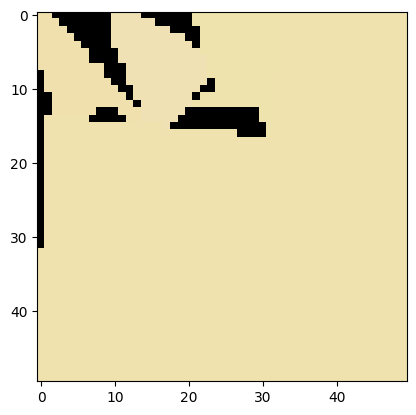

In [ ]:
# clip sampled points to image bounds
imRecover = np.zeros((img.shape[0], img.shape[1], 3), dtype=np.uint8)
clusters_to_draw = []
H, W = img.shape[:2]


def sample_cubic_bezier(p0, p1, p2, p3, n_samples=24):
    pts = []
    n_samples = max(2, int(n_samples))
    for t in np.linspace(0.0, 1.0, n_samples):
        a = (1 - t) ** 3
        b = 3 * (1 - t) ** 2 * t
        c = 3 * (1 - t) * t ** 2
        d = t ** 3
        p = a * p0 + b * p1 + c * p2 + d * p3

        rr = int(round(np.clip(p[0], 0, H - 1)))
        cc = int(round(np.clip(p[1], 0, W - 1)))
        pts.append([cc, rr])
    return pts


def parse_loop_line(parts):
    pts = []
    for tok in parts[1:]:
        if not tok:
            continue
        rc = tok.split(',')
        if len(rc) != 2:
            continue
        try:
            r = float(rc[0])
            c = float(rc[1])
        except ValueError:
            continue
        rr = int(round(np.clip(r, 0, H - 1)))
        cc = int(round(np.clip(c, 0, W - 1)))
        pts.append([cc, rr])
    return pts


with open("imComp.txt", "r") as f:
    current_cluster = None

    for line in f:
        l = line.strip().split(';')
        if len(l) == 0 or l[0] == '':
            continue

        if l[0] == 'C':
            color = np.array([int(i) for i in l[1].split(',')])
            current_cluster = {'color': color, 'pts': []}
            clusters_to_draw.append(current_cluster)

        elif l[0] == 'B' and current_cluster is not None:
            p0 = np.array([float(v) for v in l[1].split(',')])
            p1 = np.array([float(v) for v in l[2].split(',')])
            p2 = np.array([float(v) for v in l[3].split(',')])
            p3 = np.array([float(v) for v in l[4].split(',')])

            chord = np.linalg.norm(p3 - p0)
            n_samples = max(8, int(chord * 1.5))
            current_cluster['pts'].extend(sample_cubic_bezier(p0, p1, p2, p3, n_samples=n_samples))

        elif l[0] == 'L' and current_cluster is not None:
            current_cluster['pts'].extend(parse_loop_line(l))

        elif l[0] == 'P' and current_cluster is not None:
            startPt = int(l[1])
            poly_coeffs = [float(i) for i in l[2].split(',')]
            p = np.poly1d(poly_coeffs)
            endPt = int(l[3])

            step = 1 if endPt >= startPt else -1
            for r in range(startPt, endPt + step, step):
                rr = int(np.clip(r, 0, H - 1))
                cc = int(np.clip(int(round(p(r))), 0, W - 1))
                current_cluster['pts'].append([cc, rr])

        elif l[0] == 'V' and current_cluster is not None:
            r_start, c_start = [int(k) for k in l[1].split(',')]
            r_end, c_end = [int(k) for k in l[2].split(',')]

            steps = max(abs(r_end - r_start), abs(c_end - c_start))
            if steps > 0:
                for s in range(steps + 1):
                    rr = int(r_start + s * (r_end - r_start) / steps)
                    cc = int(c_start + s * (c_end - c_start) / steps)
                    rr = int(np.clip(rr, 0, H - 1))
                    cc = int(np.clip(cc, 0, W - 1))
                    current_cluster['pts'].append([cc, rr])

clusters_to_draw.sort(key=lambda x: len(x['pts']), reverse=True)

for cluster in clusters_to_draw:
    if len(cluster['pts']) > 2:
        polygon_points = np.array(cluster['pts'], dtype=np.int32).reshape((-1, 1, 2))
        cv2.fillPoly(imRecover, [polygon_points], color=cluster['color'].tolist())

plt.imshow(cv2.cvtColor(imRecover, cv2.COLOR_HSV2RGB))
plt.show()



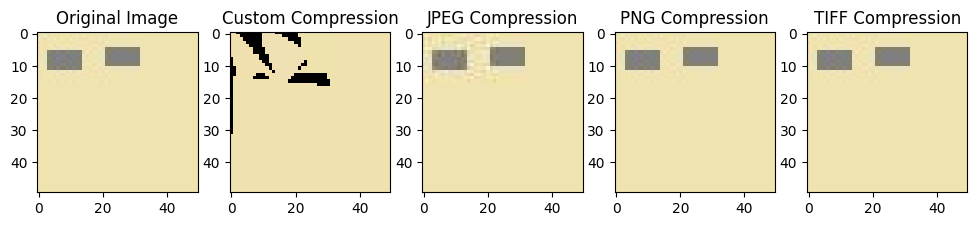

In [15]:
imj = cv2.imread('test.jpg')
imp = cv2.imread('test.png')
imt = cv2.imread('test.tiff')
f, axarr = plt.subplots(1,5, figsize=(12, 6))
axarr[0].imshow(chosenImage[...,::-1])
axarr[0].title.set_text('Original Image')
axarr[1].imshow(cv2.cvtColor(imRecover, cv2.COLOR_HSV2RGB))
axarr[1].title.set_text('Custom Compression')
axarr[2].imshow(imj[...,::-1])  # BGR to RGB for matplotlib
axarr[2].title.set_text('JPEG Compression')
axarr[3].imshow(imp[...,::-1])  # BGR to RGB for matplotlib
axarr[3].title.set_text('PNG Compression')
axarr[4].imshow(imt[...,::-1])  # BGR to RGB for matplotlib
axarr[4].title.set_text('TIFF Compression')